# Paper 2 — Goal 2 FINAL figure package and freeze — v1.2

**Purpose.** This notebook is the final Goal 2 post-processing notebook. It does **not** refit predictive models. It reads the authoritative outputs produced by the completed Goal 2 pipeline and regenerates the complete publication figure package from machine-readable results.

It performs six jobs:

1. locate and validate the authoritative Goal 2 completion outputs;
2. regenerate **Figure 3** — consequence of accounting for recording quality on clinical inference;
3. regenerate the correct prespecified **Figure 4** separately for diagnosis and severity, including paired-loss-change panels;
4. generate **Figure S3** — native out-of-fold diagnosis calibration;
5. generate cleaned **Figure S6** — prespecified sensitivity analyses and Q-family ablations;
6. review the overlap diagnostics and, if the prespecified overlap sensitivity is not triggered, write a final Goal 2 `DONE.json` seal.

### Scientific interpretation boundary

Goal 2 is observational. Differences after adding Q, residualizing the acoustic representation against Q, or detecting Q-dependent error demonstrate **dependence/sensitivity within the observed cohort and recording distribution**. They do **not** identify a uniquely technical cause, prove shortcut learning, or reconstruct artifact-free physiology.

### Run instruction

Run this notebook only **after** the Goal 2 completion notebook has successfully generated its authoritative OOF predictions, bootstrap tables, Q-loss associations, sensitivity results, family ablations, and overlap diagnostics.

Use **Kernel → Restart Kernel and Run All Cells**.

**v1.2 export rule:** all final publication figures are written to `outputs/goal2/FINAL_FIGURES/`. Authoritative numerical source tables remain in the governed Goal 2 completion directory.

In [4]:
from __future__ import annotations

import hashlib
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

MODELS = ["M_A", "M_A+Q", "M_A-resQ"]
FAMILY_ORDER = ["QADD", "QGAIN", "QREV", "QCHAN"]

MODEL_DISPLAY = {
    "M_A": "A",
    "M_A+Q": "A + Q",
    "M_A-resQ": "A residualized on Q",
}

PALETTE = {
    "M_A": "#203D5B",
    "M_A+Q": "#167C80",
    "M_A-resQ": "#A65345",
    "QADD": "#3D78A8",
    "QGAIN": "#C67645",
    "QREV": "#52866B",
    "QCHAN": "#846A98",
    "neutral": "#6B7280",
    "light": "#D9DEE5",
}

MM_TO_IN = 1 / 25.4

mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6.2,
    "ytick.labelsize": 6.2,
    "legend.fontsize": 6.2,
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

def clean_ax(ax):
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", pad=2)

def plabel(ax, label):
    ax.text(
        -0.12, 1.04, label,
        transform=ax.transAxes,
        fontsize=8.5,
        fontweight="bold",
        va="bottom",
        ha="left",
        clip_on=False,
    )

def sha256_file(path: Path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(chunk_size), b""):
            h.update(block)
    return h.hexdigest()

def atomic_json(payload, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    temp.write_text(json.dumps(payload, indent=2, default=str), encoding="utf-8")
    os.replace(temp, path)

def atomic_csv(frame: pd.DataFrame, path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temp = path.with_suffix(path.suffix + ".tmp")
    frame.to_csv(temp, index=False)
    os.replace(temp, path)

def export_figure(fig, stem: str):
    """Write publication master files without cropping labels or legends."""
    FIGURES.mkdir(parents=True, exist_ok=True)
    outputs = []
    for ext, kwargs in [
        ("pdf", {}),
        ("svg", {}),
        ("png", {"dpi": 600}),
    ]:
        path = FIGURES / f"{stem}.{ext}"
        fig.savefig(
            path,
            bbox_inches="tight",
            pad_inches=0.06,
            facecolor="white",
            **kwargs,
        )
        outputs.append(path)
    return outputs

print("Imports and publication visual system: READY")

Imports and publication visual system: READY


## 1. Locate the Paper 2 repository and authoritative Goal 2 completion output

The authoritative completion directory used by the final Goal 2 notebook is expected at:

`outputs/goal2/goal2_completion_v1_0/final`

The cell also accepts an explicit `PAPER2_ROOT` environment variable and includes a conservative fallback search.

In [5]:
def find_project_root() -> Path:
    override = os.environ.get("PAPER2_ROOT", "").strip()
    if override:
        p = Path(override).expanduser().resolve()
        if (p / "outputs" / "goal2").exists():
            return p
        raise FileNotFoundError(f"Invalid PAPER2_ROOT: {p}")

    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "outputs" / "goal2").exists() and (p / "data").exists():
            return p

    raise FileNotFoundError(
        "Could not identify the Paper 2 project root. "
        "Set PAPER2_ROOT to the repository root and rerun."
    )

ROOT = find_project_root()

preferred = ROOT / "outputs" / "goal2" / "goal2_completion_v1_0" / "final"
if preferred.exists():
    OUT = preferred
else:
    candidates = sorted(
        (ROOT / "outputs" / "goal2").glob("goal2_completion*/final"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        raise FileNotFoundError(
            "No Goal 2 completion FINAL output directory was found."
        )
    OUT = candidates[0]

# Governed machine-readable inputs remain here:
TABLES = OUT / "tables"
OOF_DIR = OUT / "oof"
SOURCE_FIGURES = OUT / "figures"

# Publication-ready exports go to a deliberately separate, simple folder.
FIGURES = ROOT / "outputs" / "goal2" / "FINAL_FIGURES"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Paper 2 root:", ROOT)
print("Authoritative Goal 2 completion directory:", OUT)
print("FINAL publication figure folder:", FIGURES)

Paper 2 root: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code
Authoritative Goal 2 completion directory: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final
FINAL publication figure folder: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\FINAL_FIGURES


## 2. Hard source-table gate

All figures below must be regenerated from saved machine-readable authoritative results. No result is hand-entered.

Required sources include the corrected authoritative OOF predictions, paired 2,000-participant-bootstrap contrasts, prediction shifts, Q-error GEE associations, sensitivity summary, family ablations, and overlap diagnostics.

In [6]:
SOURCE_FILES = {
    "dx_oof": OOF_DIR / "goal2_diagnosis_oof_authoritative.csv",
    "sev_oof": OOF_DIR / "goal2_severity_oof_authoritative.csv",
    "dx_final": TABLES / "goal2_dx_participant_oof_authoritative.csv",
    "metrics": TABLES / "goal2_metrics_authoritative.csv",
    "shifts": TABLES / "goal2_prediction_shifts_authoritative.csv",
    "q_assoc": TABLES / "goal2_q_error_associations.csv",
    "sensitivity": TABLES / "goal2_sensitivity_summary.csv",
    "ablations": TABLES / "goal2_family_ablations.csv",
    "overlap": TABLES / "goal2_overlap_diagnostics.csv",
    "protocol_audit": TABLES / "goal2_protocol_concordance_audit.csv",
    "residualizer_manifest": TABLES / "goal2_corrected_residualizer_fold_manifest.csv",
}

missing = [str(p) for p in SOURCE_FILES.values() if not p.exists() or p.stat().st_size == 0]
if missing:
    raise RuntimeError(
        "Cannot build the final Goal 2 figure package. Missing/empty authoritative sources:\n"
        + "\n".join(missing)
    )

dx_oof = pd.read_csv(SOURCE_FILES["dx_oof"], low_memory=False)
sev_oof = pd.read_csv(SOURCE_FILES["sev_oof"], low_memory=False)
dx_final = pd.read_csv(SOURCE_FILES["dx_final"], low_memory=False)
authoritative_bootstrap = pd.read_csv(SOURCE_FILES["metrics"], low_memory=False)
prediction_shifts = pd.read_csv(SOURCE_FILES["shifts"], low_memory=False)
q_error_associations = pd.read_csv(SOURCE_FILES["q_assoc"], low_memory=False)
sensitivity_summary = pd.read_csv(SOURCE_FILES["sensitivity"], low_memory=False)
family_ablations = pd.read_csv(SOURCE_FILES["ablations"], low_memory=False)
overlap_diagnostics = pd.read_csv(SOURCE_FILES["overlap"], low_memory=False)

for label, df in [
    ("diagnosis OOF", dx_oof),
    ("severity OOF", sev_oof),
    ("diagnosis participant OOF", dx_final),
]:
    observed = set(df["model"].astype(str))
    if observed != set(MODELS):
        raise RuntimeError(f"{label}: unexpected model set: {sorted(observed)}")

if int(authoritative_bootstrap["bootstrap_replicates"].min()) != 2000:
    raise RuntimeError("Authoritative Goal 2 paired bootstrap table is not the FINAL 2,000-replicate run.")

required_assoc = {
    "task", "q_feature", "q_family", "model", "component",
    "effect_per_1IQR_Q", "ci_low", "ci_high",
    "p_value", "cov_structure", "status"
}
missing_assoc = required_assoc - set(q_error_associations.columns)
if missing_assoc:
    raise RuntimeError(f"Q-error association table missing columns: {sorted(missing_assoc)}")

print("AUTHORITATIVE SOURCE GATE: PASS")
print("Paired bootstrap replicates:", int(authoritative_bootstrap["bootstrap_replicates"].min()))
display(authoritative_bootstrap)

AUTHORITATIVE SOURCE GATE: PASS
Paired bootstrap replicates: 2000


,task,contrast,metric,estimate,ci_low,ci_high,bootstrap_replicates
0,diagnosis,M_A+Q minus M_A,AUROC,0.050309,0.009286,0.093498,2000
1,diagnosis,M_A+Q minus M_A,Brier,-0.018991,-0.032346,-0.006452,2000
2,diagnosis,M_A+Q minus M_A,CalibrationIntercept,-0.000285,-0.122796,0.120579,2000
3,diagnosis,M_A+Q minus M_A,CalibrationSlope,0.113820,-0.256436,0.500842,2000
4,severity,M_A+Q minus M_A,MAE,-0.078697,-0.162924,0.011051,2000
5,severity,M_A+Q minus M_A,RMSE,-0.103196,-0.204614,-0.000364,2000
6,diagnosis,M_A-resQ minus M_A,AUROC,-0.099166,-0.160163,-0.047627,2000
7,diagnosis,M_A-resQ minus M_A,Brier,0.021969,0.011017,0.032924,2000
8,diagnosis,M_A-resQ minus M_A,CalibrationIntercept,0.004741,-0.087600,0.104017,2000
9,diagnosis,M_A-resQ minus M_A,CalibrationSlope,-0.104610,-0.459295,0.280721,2000


## 3. Figure 3 — Does accounting for Q change inference?

This is the primary Goal 2 performance/consequence figure.

- **A:** paired diagnosis ΔAUROC and ΔBrier for `M_A+Q` and `M_A-resQ` versus `M_A`;
- **B:** empirical survival curves for absolute participant-level probability shifts, with 0.05 and 0.10 descriptive anchors;
- **C:** paired severity ΔMAE and ΔRMSE;
- **D:** empirical survival curves for absolute predicted bulbar-score shifts, with a 1-point descriptive anchor.

The anchors are visualization guides only; they are not clinical thresholds.

**Layout rule:** legends are kept in unused plot space; labels and panel letters are exported with extra padding so nothing is clipped.

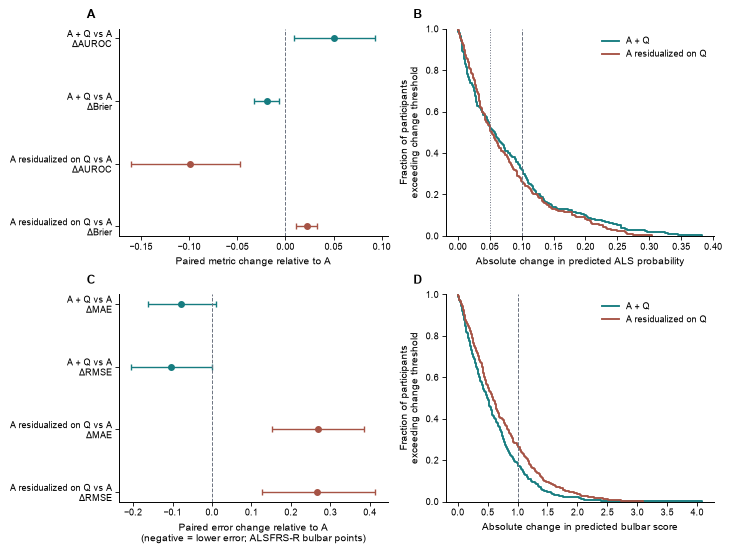

FIGURE 3: PASS
Saved to: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\FINAL_FIGURES


In [7]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(183 * MM_TO_IN, 138 * MM_TO_IN),
    constrained_layout=True,
)

# A — diagnosis paired performance changes
ax = axes[0, 0]
d = authoritative_bootstrap.loc[
    authoritative_bootstrap["task"].eq("diagnosis")
    & authoritative_bootstrap["metric"].isin(["AUROC", "Brier"])
].copy()

pretty_contrast = {
    "M_A+Q minus M_A": "A + Q vs A",
    "M_A-resQ minus M_A": "A residualized on Q vs A",
}
d["label"] = [
    f"{pretty_contrast.get(c, c)}\nΔ{m}"
    for c, m in zip(d["contrast"], d["metric"])
]
y = np.arange(len(d))
x = d["estimate"].to_numpy(float)
lo = d["ci_low"].to_numpy(float)
hi = d["ci_high"].to_numpy(float)
colors = [
    PALETTE["M_A+Q"] if c.startswith("M_A+Q") else PALETTE["M_A-resQ"]
    for c in d["contrast"]
]

for yi, xi, l, h, c in zip(y, x, lo, hi, colors):
    ax.errorbar(
        xi, yi,
        xerr=[[xi - l], [h - xi]],
        fmt="o", color=c,
        capsize=2, linewidth=1, markersize=4,
    )

ax.axvline(0, color=PALETTE["neutral"], linestyle="--", linewidth=0.7)
ax.set_yticks(y)
ax.set_yticklabels(d["label"])
ax.invert_yaxis()
ax.set_xlabel("Paired metric change relative to A")
clean_ax(ax)
plabel(ax, "A")

# B — diagnosis absolute prediction shifts
ax = axes[0, 1]
for comparison, color, label in [
    ("M_A+Q minus M_A", PALETTE["M_A+Q"], "A + Q"),
    ("M_A-resQ minus M_A", PALETTE["M_A-resQ"], "A residualized on Q"),
]:
    vals = np.sort(
        prediction_shifts.loc[
            prediction_shifts["task"].eq("diagnosis")
            & prediction_shifts["comparison"].eq(comparison),
            "absolute_shift",
        ].to_numpy(float)
    )
    if len(vals):
        surv = 1 - np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, surv, where="post", color=color, linewidth=1.35, label=label)

for anchor, ls in [(0.05, ":"), (0.10, "--")]:
    ax.axvline(anchor, color=PALETTE["neutral"], linestyle=ls, linewidth=0.7)

ax.set_xlabel("Absolute change in predicted ALS probability")
ax.set_ylabel("Fraction of participants\nexceeding change threshold")
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper right")
clean_ax(ax)
plabel(ax, "B")

# C — severity paired performance changes
ax = axes[1, 0]
s = authoritative_bootstrap.loc[
    authoritative_bootstrap["task"].eq("severity")
    & authoritative_bootstrap["metric"].isin(["MAE", "RMSE"])
].copy()

s["label"] = [
    f"{pretty_contrast.get(c, c)}\nΔ{m}"
    for c, m in zip(s["contrast"], s["metric"])
]
y = np.arange(len(s))
x = s["estimate"].to_numpy(float)
lo = s["ci_low"].to_numpy(float)
hi = s["ci_high"].to_numpy(float)
colors = [
    PALETTE["M_A+Q"] if c.startswith("M_A+Q") else PALETTE["M_A-resQ"]
    for c in s["contrast"]
]

for yi, xi, l, h, c in zip(y, x, lo, hi, colors):
    ax.errorbar(
        xi, yi,
        xerr=[[xi - l], [h - xi]],
        fmt="o", color=c,
        capsize=2, linewidth=1, markersize=4,
    )

ax.axvline(0, color=PALETTE["neutral"], linestyle="--", linewidth=0.7)
ax.set_yticks(y)
ax.set_yticklabels(s["label"])
ax.invert_yaxis()
ax.set_xlabel(
    "Paired error change relative to A\n"
    "(negative = lower error; ALSFRS-R bulbar points)"
)
clean_ax(ax)
plabel(ax, "C")

# D — severity absolute prediction shifts
ax = axes[1, 1]
for comparison, color, label in [
    ("M_A+Q minus M_A", PALETTE["M_A+Q"], "A + Q"),
    ("M_A-resQ minus M_A", PALETTE["M_A-resQ"], "A residualized on Q"),
]:
    vals = np.sort(
        prediction_shifts.loc[
            prediction_shifts["task"].eq("severity")
            & prediction_shifts["comparison"].eq(comparison),
            "absolute_shift",
        ].to_numpy(float)
    )
    if len(vals):
        surv = 1 - np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, surv, where="post", color=color, linewidth=1.35, label=label)

ax.axvline(1.0, color=PALETTE["neutral"], linestyle="--", linewidth=0.7)
ax.set_xlabel("Absolute change in predicted bulbar score")
ax.set_ylabel("Fraction of participants\nexceeding change threshold")
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="upper right")
clean_ax(ax)
plabel(ax, "D")

stem = "Figure3_Goal2_inference_change_PUBLICATION_FINAL"
export_figure(fig, stem)
plt.show()

print("FIGURE 3: PASS")
print("Saved to:", FIGURES)

## 4. Figure 4 — Is prediction error quality-dependent?

This is the prespecified Goal 2 error-dependence figure and is generated **separately for diagnosis and severity**.

For each task:

- **A:** between-participant Q dependence of OOF loss across `M_A`, `M_A+Q`, and `M_A-resQ`;
- **B:** within-participant Q-deviation dependence of OOF loss across the same three models;
- **C:** Q dependence of paired loss change \(L_{A+Q}-L_A\);
- **D:** Q dependence of paired loss change \(L_{A-resQ}-L_A\).

All effects are displayed per natural **1-IQR Q**. The primary estimates use the prespecified independence working correlation with participant-cluster-robust covariance. BH-FDR-adjusted q-values remain in the source table for inference; the plotted uncertainty is the robust 95% CI.

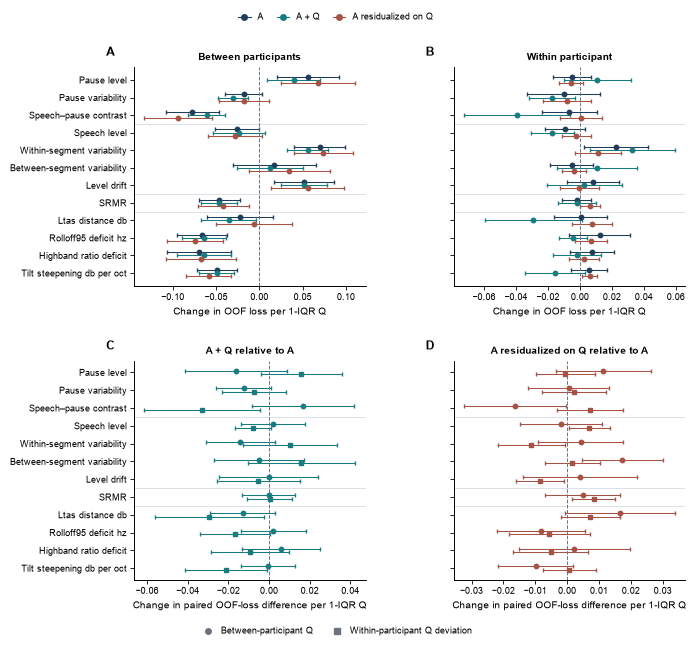

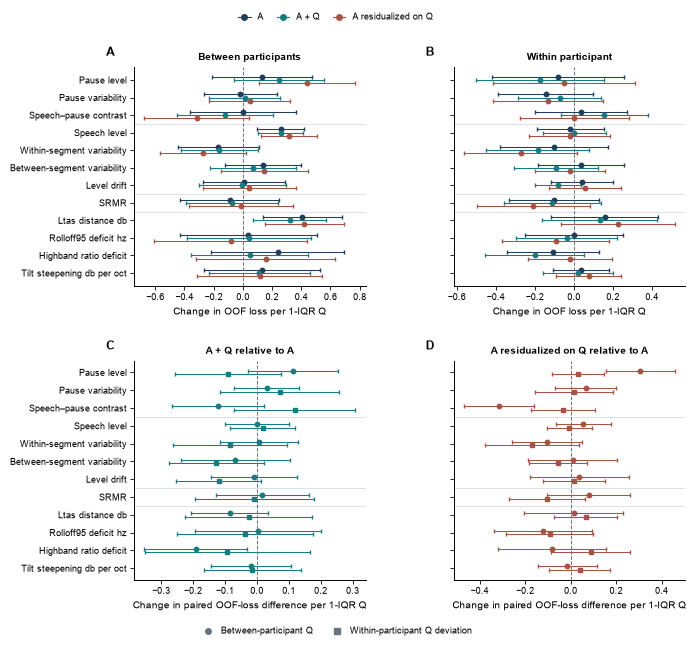

FIGURE 4 DIAGNOSIS + SEVERITY: PASS
Saved to: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\FINAL_FIGURES


In [8]:
primary_assoc = q_error_associations.loc[
    q_error_associations["cov_structure"].eq("independence")
    & q_error_associations["status"].eq("ok")
].copy()

q_meta = (
    primary_assoc.loc[
        primary_assoc["model"].eq("M_A")
        & primary_assoc["component"].eq("between"),
        ["q_feature", "q_family"],
    ]
    .drop_duplicates()
)
q_meta["family_rank"] = q_meta["q_family"].map(
    {f: i for i, f in enumerate(FAMILY_ORDER)}
).fillna(99)
q_meta["_order"] = np.arange(len(q_meta))
q_meta = q_meta.sort_values(["family_rank", "_order"])
q_order = q_meta["q_feature"].tolist()

def short_q_label(q):
    replacements = {
        "qadd_pause_ac_level_dbfs_median": "Pause level",
        "qadd_pause_level_iqr_db": "Pause variability",
        "qadd_speech_pause_level_contrast_db": "Speech–pause contrast",
        "qgain_typical_speech_level_dbfs": "Speech level",
        "qgain_within_segment_iqr_db": "Within-segment variability",
        "qgain_between_segment_mad_db": "Between-segment variability",
        "qgain_abs_drift_db_per_min": "Level drift",
        "qrev_srmr_norm": "SRMR",
    }
    if q in replacements:
        return replacements[q]

    label = str(q).replace("_proc", "")
    label = label.replace("qchan_", "")
    label = label.replace("_", " ")
    label = label.replace("speech centroid hz", "LTAS distance")
    label = label.replace("speech rolloff95 hz", "Rolloff-95 deficit")
    label = label.replace("speech highband", "High-band deficit")
    label = label.replace("speech tilt", "Tilt steepening")
    return label[:1].upper() + label[1:]

MODEL_OFFSETS = {"M_A": -0.18, "M_A+Q": 0.0, "M_A-resQ": 0.18}

def _checked_reindex(z, context):
    z = z.set_index("q_feature").reindex(q_order)
    if z["effect_per_1IQR_Q"].isna().any():
        missing = z.index[z["effect_per_1IQR_Q"].isna()].tolist()
        raise RuntimeError(f"{context}: missing Q effects for {missing}")
    return z

# separators between Q families
ordered_families = (
    q_meta.set_index("q_feature")
    .reindex(q_order)["q_family"]
    .astype(str)
    .tolist()
)
separator_positions = [
    i + 0.5
    for i in range(len(ordered_families) - 1)
    if ordered_families[i] != ordered_families[i + 1]
]

def add_family_separators(ax):
    for yy in separator_positions:
        ax.axhline(yy, color=PALETTE["light"], linewidth=0.65, zorder=0)

def make_figure4_for_task(task):
    local = primary_assoc.loc[primary_assoc["task"].eq(task)].copy()

    fig, axes = plt.subplots(
        2, 2,
        figsize=(183 * MM_TO_IN, 166 * MM_TO_IN),
    )
    fig.subplots_adjust(
        left=0.22, right=0.985, top=0.89, bottom=0.105,
        wspace=0.38, hspace=0.34,
    )

    def forest_models(ax, component, show_ylabels):
        for model in MODELS:
            z = _checked_reindex(
                local.loc[
                    local["model"].eq(model)
                    & local["component"].eq(component)
                ].copy(),
                f"{task}/{component}/{model}",
            )

            yy = np.arange(len(q_order)) + MODEL_OFFSETS[model]
            x = z["effect_per_1IQR_Q"].to_numpy(float)
            lo = z["ci_low"].to_numpy(float)
            hi = z["ci_high"].to_numpy(float)

            ax.errorbar(
                x, yy,
                xerr=np.vstack([x - lo, hi - x]),
                fmt="o",
                color=PALETTE[model],
                capsize=1.7,
                linewidth=0.75,
                markersize=3.2,
            )

        ax.axvline(0, color=PALETTE["neutral"], linestyle="--", linewidth=0.7)
        add_family_separators(ax)
        ax.set_yticks(np.arange(len(q_order)))
        if show_ylabels:
            ax.set_yticklabels([short_q_label(q) for q in q_order])
        else:
            ax.set_yticklabels([])
        ax.invert_yaxis()
        clean_ax(ax)

    def forest_delta(ax, model_name, color, show_ylabels):
        for component, offset, marker in [
            ("between", -0.10, "o"),
            ("within", +0.10, "s"),
        ]:
            z = _checked_reindex(
                local.loc[
                    local["model"].eq(model_name)
                    & local["component"].eq(component)
                ].copy(),
                f"{task}/{model_name}/{component}",
            )
            yy = np.arange(len(q_order)) + offset
            x = z["effect_per_1IQR_Q"].to_numpy(float)
            lo = z["ci_low"].to_numpy(float)
            hi = z["ci_high"].to_numpy(float)

            ax.errorbar(
                x, yy,
                xerr=np.vstack([x - lo, hi - x]),
                fmt=marker,
                color=color,
                capsize=1.7,
                linewidth=0.75,
                markersize=3.2,
            )

        ax.axvline(0, color=PALETTE["neutral"], linestyle="--", linewidth=0.7)
        add_family_separators(ax)
        ax.set_yticks(np.arange(len(q_order)))
        if show_ylabels:
            ax.set_yticklabels([short_q_label(q) for q in q_order])
        else:
            ax.set_yticklabels([])
        ax.invert_yaxis()
        clean_ax(ax)

    # A
    forest_models(axes[0, 0], "between", True)
    axes[0, 0].set_title("Between participants", fontweight="bold", pad=5)
    axes[0, 0].set_xlabel("Change in OOF loss per 1-IQR Q")
    plabel(axes[0, 0], "A")

    # B
    forest_models(axes[0, 1], "within", False)
    axes[0, 1].set_title("Within participant", fontweight="bold", pad=5)
    axes[0, 1].set_xlabel("Change in OOF loss per 1-IQR Q")
    plabel(axes[0, 1], "B")

    # C
    forest_delta(
        axes[1, 0],
        "M_A+Q-minus-M_A-loss",
        PALETTE["M_A+Q"],
        True,
    )
    axes[1, 0].set_title("A + Q relative to A", fontweight="bold", pad=5)
    axes[1, 0].set_xlabel("Change in paired OOF-loss difference per 1-IQR Q")
    plabel(axes[1, 0], "C")

    # D
    forest_delta(
        axes[1, 1],
        "M_A-resQ-minus-M_A-loss",
        PALETTE["M_A-resQ"],
        False,
    )
    axes[1, 1].set_title("A residualized on Q relative to A", fontweight="bold", pad=5)
    axes[1, 1].set_xlabel("Change in paired OOF-loss difference per 1-IQR Q")
    plabel(axes[1, 1], "D")

    # Figure-level legends stay completely outside all data regions.
    model_handles = [
        Line2D(
            [0], [0],
            marker="o", linestyle="-", linewidth=0.8,
            markersize=4, color=PALETTE[m],
            label=MODEL_DISPLAY[m],
        )
        for m in MODELS
    ]
    fig.legend(
        handles=model_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=3,
        frameon=False,
        columnspacing=1.6,
        handlelength=1.4,
    )

    component_handles = [
        Line2D(
            [0], [0],
            marker="o", linestyle="none",
            markersize=4, color=PALETTE["neutral"],
            label="Between-participant Q",
        ),
        Line2D(
            [0], [0],
            marker="s", linestyle="none",
            markersize=4, color=PALETTE["neutral"],
            label="Within-participant Q deviation",
        ),
    ]
    fig.legend(
        handles=component_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.008),
        ncol=2,
        frameon=False,
        columnspacing=1.8,
        handletextpad=0.5,
    )

    stem = f"Figure4_Goal2_Q_dependent_error_{task}_PUBLICATION_FINAL"
    export_figure(fig, stem)
    plt.show()
    return stem

fig4_dx = make_figure4_for_task("diagnosis")
fig4_sev = make_figure4_for_task("severity")

print("FIGURE 4 DIAGNOSIS + SEVERITY: PASS")
print("Saved to:", FIGURES)

## 5. Figure 4 inference audit table

The figure itself should remain visually restrained. This cell gives the exact primary robust estimates and highlights which tests survive the stored BH-FDR correction where `q_value` is available.

This table is for manuscript writing/audit, not an additional figure.

In [9]:
audit_cols = [
    c for c in [
        "task", "q_feature", "q_family", "model", "component",
        "effect_per_1IQR_Q", "ci_low", "ci_high", "p_value", "q_value"
    ]
    if c in primary_assoc.columns
]

figure4_audit = primary_assoc[audit_cols].copy()
if "q_value" in figure4_audit.columns:
    figure4_audit["fdr_lt_0p05"] = figure4_audit["q_value"] < 0.05

figure4_audit = figure4_audit.sort_values(
    [c for c in ["task", "component", "q_family", "q_value", "p_value"] if c in figure4_audit.columns]
)

atomic_csv(figure4_audit, TABLES / "goal2_figure4_inference_audit_FINAL.csv")
display(figure4_audit)

print("FIGURE 4 INFERENCE AUDIT TABLE: WRITTEN")

,task,q_feature,q_family,model,component,effect_per_1IQR_Q,ci_low,ci_high,p_value,q_value,fdr_lt_0p05
42,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A+Q,between,-0.060886,-0.082488,-0.039284,3.305926e-08,9.917777e-08,True
40,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A,between,-0.077511,-0.108391,-0.046630,8.669236e-07,2.600771e-06,True
44,diagnosis,qadd_speech_pause_level_contrast_db,QADD,M_A-resQ,between,-0.093797,-0.132703,-0.054891,2.297808e-06,6.893424e-06,True
22,diagnosis,qadd_pause_level_iqr_db,QADD,M_A+Q,between,-0.030647,-0.047824,-0.013469,4.706912e-04,7.060368e-04,True
0,diagnosis,qadd_pause_ac_level_dbfs_median,QADD,M_A,between,0.056076,0.020435,0.091717,2.043976e-03,3.065963e-03,True
...,...,...,...,...,...,...,...,...,...,...,...
403,severity,qrev_srmr_norm,QREV,M_A-resQ,within,-0.207352,-0.497086,0.082381,1.607050e-01,1.607050e-01,False
407,severity,qrev_srmr_norm,QREV,M_A-resQ-minus-M_A-loss,within,-0.104821,-0.272939,0.063298,2.216897e-01,2.216897e-01,False
401,severity,qrev_srmr_norm,QREV,M_A+Q,within,-0.110323,-0.357403,0.136757,3.814898e-01,3.814898e-01,False
399,severity,qrev_srmr_norm,QREV,M_A,within,-0.102532,-0.332992,0.127929,3.832077e-01,3.832077e-01,False


FIGURE 4 INFERENCE AUDIT TABLE: WRITTEN


## 6. Figure S3 — native out-of-fold diagnosis calibration

The final participant-level diagnosis predictions are the average cross-fitted predictions across repeats. The calibration display uses a LOWESS curve and reports calibration-in-the-large and slope descriptively.

This is a supplementary diagnostic. No post-hoc recalibration is performed.

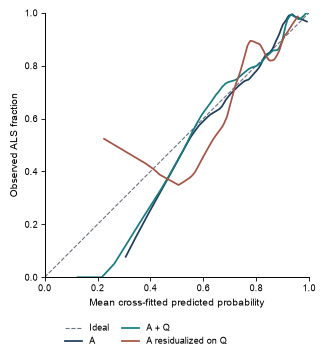

,model,n_participants,calibration_intercept_display,calibration_slope_display
0,M_A,199,-0.015149,1.361706
1,M_A+Q,199,-0.015014,1.435583
2,M_A-resQ,199,-0.010166,1.191671


FIGURE S3: PASS
Saved to: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\FINAL_FIGURES


In [10]:
def safe_calibration_stats(y, p):
    y = np.asarray(y, float)
    p = np.clip(np.asarray(p, float), 1e-6, 1 - 1e-6)

    if len(np.unique(y)) < 2:
        return np.nan, np.nan

    lp = np.log(p / (1 - p))

    try:
        intercept = float(
            sm.GLM(
                y,
                np.ones((len(y), 1)),
                family=sm.families.Binomial(),
                offset=lp,
            ).fit().params[0]
        )
    except Exception:
        intercept = np.nan

    try:
        slope = float(
            sm.GLM(
                y,
                sm.add_constant(lp),
                family=sm.families.Binomial(),
            ).fit().params[1]
        )
    except Exception:
        slope = np.nan

    return intercept, slope

fig, ax = plt.subplots(
    figsize=(98 * MM_TO_IN, 92 * MM_TO_IN),
)
fig.subplots_adjust(left=0.18, right=0.98, top=0.97, bottom=0.24)

ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    color=PALETTE["neutral"],
    linewidth=0.8,
    label="Ideal",
)

cal_rows = []

for model in MODELS:
    g = dx_final.loc[dx_final["model"].eq(model)].copy()
    g = g.dropna(subset=["y", "prediction"])

    smooth = lowess(
        g["y"].to_numpy(float),
        g["prediction"].to_numpy(float),
        frac=0.40,
        it=0,
        return_sorted=True,
    )

    ax.plot(
        smooth[:, 0],
        np.clip(smooth[:, 1], 0, 1),
        color=PALETTE[model],
        linewidth=1.25,
        label=MODEL_DISPLAY[model],
    )

    intercept, slope = safe_calibration_stats(
        g["y"].to_numpy(float),
        g["prediction"].to_numpy(float),
    )

    cal_rows.append({
        "model": model,
        "n_participants": int(g["participant_id"].nunique()),
        "calibration_intercept_display": intercept,
        "calibration_slope_display": slope,
    })

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Mean cross-fitted predicted probability")
ax.set_ylabel("Observed ALS fraction")
clean_ax(ax)

# Legend outside the plotting region: no curve/legend collision is possible.
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.03),
    ncol=2,
    frameon=False,
    columnspacing=1.5,
)

cal_display = pd.DataFrame(cal_rows)
atomic_csv(
    cal_display,
    TABLES / "goal2_diagnosis_calibration_display_FINAL.csv",
)

stem = "FigureS3_Goal2_native_calibration_PUBLICATION_FINAL"
export_figure(fig, stem)
plt.show()

display(cal_display)
print("FIGURE S3: PASS")
print("Saved to:", FIGURES)

## 7. Figure S6 — robustness and Q-family localization

The supplementary sensitivity figure is retained, but implementation strings are converted to paper-facing labels.

- **A:** diagnosis sensitivity analyses;
- **B:** severity sensitivity analyses;
- **C:** diagnosis Q-family add-one and leave-one-out localization;
- **D:** severity Q-family add-one and leave-one-out localization.

Family-ablation inferences remain secondary localization analyses.

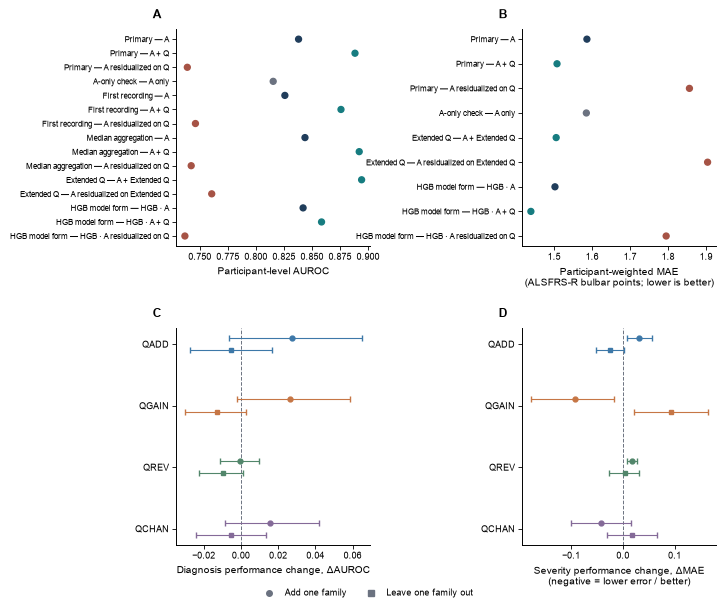

FIGURE S6: PASS
Saved to: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\FINAL_FIGURES


In [11]:
def model_color(name):
    n = str(name).replace("HGB_", "")
    if "resExtendedQ" in n:
        return PALETTE["M_A-resQ"]
    if "ExtendedQ" in n:
        return PALETTE["M_A+Q"]
    if n == "A-only":
        return PALETTE["neutral"]
    return PALETTE.get(n, PALETTE["neutral"])

def pretty_model(name):
    mapping = {
        "M_A": "A",
        "M_A+Q": "A + Q",
        "M_A-resQ": "A residualized on Q",
        "A-only": "A only",
        "M_A+ExtendedQ": "A + Extended Q",
        "M_A-resExtendedQ": "A residualized on Extended Q",
        "HGB_M_A": "HGB · A",
        "HGB_M_A+Q": "HGB · A + Q",
        "HGB_M_A-resQ": "HGB · A residualized on Q",
    }
    return mapping.get(str(name), str(name))

def pretty_sensitivity(name):
    s = str(name).strip()
    mapping = {
        "authoritative primary": "Primary",
        "primary": "Primary",
        "A-only vs Age+A": "A-only check",
        "first recording diagnosis": "First recording",
        "first-recording diagnosis": "First recording",
        "first recording only": "First recording",
        "median participant aggregation": "Median aggregation",
        "Extended-Q": "Extended Q",
        "extended Q": "Extended Q",
        "HGB": "HGB model form",
        "HGB sensitivity": "HGB model form",
        "HGB model-form": "HGB model form",
    }
    if s in mapping:
        return mapping[s]
    s = s.replace("_", " ")
    s = s.replace("authoritative", "").strip()
    return s[:1].upper() + s[1:] if s else s

fig, axes = plt.subplots(
    2, 2,
    figsize=(183 * MM_TO_IN, 154 * MM_TO_IN),
)
fig.subplots_adjust(
    left=0.235, right=0.985, top=0.965, bottom=0.115,
    wspace=0.78, hspace=0.38,
)

# A diagnosis sensitivities
ax = axes[0, 0]
d = sensitivity_summary.loc[
    sensitivity_summary["task"].eq("diagnosis")
    & sensitivity_summary["AUROC"].notna()
].copy()
labels = [
    f"{pretty_sensitivity(sens)} — {pretty_model(m)}"
    for sens, m in zip(d["sensitivity"], d["model"])
]
y = np.arange(len(d))
ax.scatter(
    d["AUROC"].to_numpy(float),
    y,
    s=18,
    c=[model_color(m) for m in d["model"]],
    zorder=3,
)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=5.7)
ax.invert_yaxis()
ax.set_xlabel("Participant-level AUROC")
clean_ax(ax)
plabel(ax, "A")

# B severity sensitivities
ax = axes[0, 1]
s = sensitivity_summary.loc[
    sensitivity_summary["task"].eq("severity")
    & sensitivity_summary["MAE"].notna()
].copy()
labels = [
    f"{pretty_sensitivity(sens)} — {pretty_model(m)}"
    for sens, m in zip(s["sensitivity"], s["model"])
]
y = np.arange(len(s))
ax.scatter(
    s["MAE"].to_numpy(float),
    y,
    s=18,
    c=[model_color(m) for m in s["model"]],
    zorder=3,
)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=5.7)
ax.invert_yaxis()
ax.set_xlabel(
    "Participant-weighted MAE\n"
    "(ALSFRS-R bulbar points; lower is better)"
)
clean_ax(ax)
plabel(ax, "B")

def family_ablation_panel(ax, task, xlabel):
    f = family_ablations.loc[family_ablations["task"].eq(task)].copy()

    for kind, offset, marker in [
        ("add_one", -0.10, "o"),
        ("leave_one_out", +0.10, "s"),
    ]:
        z = (
            f.loc[f["ablation_type"].eq(kind)]
            .set_index("q_family")
            .reindex(FAMILY_ORDER)
        )

        if z["performance_delta"].isna().any():
            missing = z.index[z["performance_delta"].isna()].tolist()
            raise RuntimeError(f"{task}: incomplete family ablation for {kind}: {missing}")

        yy = np.arange(len(FAMILY_ORDER)) + offset

        for j, family in enumerate(FAMILY_ORDER):
            est = float(z.loc[family, "performance_delta"])
            lo = float(z.loc[family, "ci_low"])
            hi = float(z.loc[family, "ci_high"])

            ax.errorbar(
                est,
                yy[j],
                xerr=[[est - lo], [hi - est]],
                fmt=marker,
                markersize=3.5,
                linewidth=0.8,
                capsize=2,
                color=PALETTE[family],
                zorder=3,
            )

    ax.axvline(0, color=PALETTE["neutral"], linestyle="--", linewidth=0.7)
    ax.set_yticks(np.arange(len(FAMILY_ORDER)))
    ax.set_yticklabels(FAMILY_ORDER)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    clean_ax(ax)

family_ablation_panel(
    axes[1, 0],
    "diagnosis",
    "Diagnosis performance change, ΔAUROC",
)
plabel(axes[1, 0], "C")

family_ablation_panel(
    axes[1, 1],
    "severity",
    "Severity performance change, ΔMAE\n"
    "(negative = lower error / better)",
)
plabel(axes[1, 1], "D")

# One figure-level legend below panels C/D — never on top of data.
ablation_handles = [
    Line2D(
        [0], [0], marker="o", linestyle="none",
        markersize=4, color=PALETTE["neutral"],
        label="Add one family",
    ),
    Line2D(
        [0], [0], marker="s", linestyle="none",
        markersize=4, color=PALETTE["neutral"],
        label="Leave one family out",
    ),
]
fig.legend(
    handles=ablation_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncol=2,
    frameon=False,
    columnspacing=1.8,
)

stem = "FigureS6_Goal2_completion_sensitivities_PUBLICATION_FINAL"
export_figure(fig, stem)
plt.show()

print("FIGURE S6: PASS")
print("Saved to:", FIGURES)

## 8. Reviewed overlap decision and conditional-sensitivity gate

The Goal 2 completion analysis intentionally did **not** define a new post-hoc numerical trimming threshold. Instead, it saved descriptive diagnosis overlap diagnostics for the 12 Core-Q features using the common portion of the control and ALS participant-level 5th–95th percentile intervals.

The saved schema is:

- `common_low`, `common_high`;
- `common_interval_nonempty`;
- `control_fraction_in_common`;
- `als_fraction_in_common`.

The final human/statistical review of these diagnostics found that all 12 Core-Q features had a non-empty central cross-diagnosis overlap interval, with substantial retained support in both groups. Therefore the prespecified *conditional* overlap-restricted sensitivity is **not triggered**.

This cell verifies that the saved table is still consistent with that reviewed state and records the decision. It does not invent a new cutoff.

In [12]:
display(overlap_diagnostics)

required_overlap_cols = {
    "q_feature",
    "common_low",
    "common_high",
    "common_interval_nonempty",
    "control_fraction_in_common",
    "als_fraction_in_common",
}

missing = required_overlap_cols - set(overlap_diagnostics.columns)
if missing:
    raise RuntimeError(
        "Unexpected overlap-diagnostic schema. Missing columns: "
        + ", ".join(sorted(missing))
    )

od = overlap_diagnostics.copy()

# Parse the governed diagnostic columns defensively.
for c in [
    "common_low",
    "common_high",
    "control_fraction_in_common",
    "als_fraction_in_common",
]:
    od[c] = pd.to_numeric(od[c], errors="coerce")

nonempty_raw = od["common_interval_nonempty"]
if pd.api.types.is_bool_dtype(nonempty_raw):
    nonempty = nonempty_raw.fillna(False)
else:
    nonempty = (
        nonempty_raw.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes", "y"])
    )

structural_ok = (
    len(od) == 12
    and od["q_feature"].nunique() == 12
    and nonempty.all()
    and np.isfinite(od["common_low"]).all()
    and np.isfinite(od["common_high"]).all()
    and (od["common_high"] > od["common_low"]).all()
    and np.isfinite(od["control_fraction_in_common"]).all()
    and np.isfinite(od["als_fraction_in_common"]).all()
    and (od["control_fraction_in_common"] > 0).all()
    and (od["als_fraction_in_common"] > 0).all()
)

summary = {
    "n_core_q_features": int(len(od)),
    "n_nonempty_common_intervals": int(nonempty.sum()),
    "minimum_control_fraction_in_common": float(
        od["control_fraction_in_common"].min()
    ),
    "minimum_als_fraction_in_common": float(
        od["als_fraction_in_common"].min()
    ),
    "median_control_fraction_in_common": float(
        od["control_fraction_in_common"].median()
    ),
    "median_als_fraction_in_common": float(
        od["als_fraction_in_common"].median()
    ),
}

display(pd.DataFrame([summary]))

if not structural_ok:
    raise RuntimeError(
        "The saved overlap diagnostics no longer match the reviewed Goal 2 state. "
        "Do not write the final DONE seal until the discrepancy is inspected."
    )

# Human/statistical adjudication of the already-generated descriptive diagnostics:
# all 12 central 5–95% cross-diagnosis intervals are non-empty, and even the
# least-overlapping feature retains substantial support in both diagnosis groups.
# The frozen Methods make overlap restriction conditional and specify no universal
# post-hoc trimming threshold. Therefore no overlap-restricted sensitivity is invoked.
decision = {
    "decision": "NOT_TRIGGERED",
    "reason": (
        "Reviewed Goal 2 overlap diagnostics: all 12 Core-Q features have finite, "
        "non-empty common control/ALS 5th–95th percentile intervals. "
        f"The minimum fractions retained in the common interval are "
        f"{summary['minimum_control_fraction_in_common']:.3f} for controls and "
        f"{summary['minimum_als_fraction_in_common']:.3f} for ALS. "
        "The prespecified conditional overlap-restricted sensitivity is therefore "
        "not invoked; no post-hoc trimming threshold was introduced."
    ),
    **summary,
}

overlap_decision = pd.DataFrame([decision])
atomic_csv(
    overlap_decision,
    TABLES / "goal2_overlap_decision_FINAL.csv",
)

display(overlap_decision)

print("=" * 76)
print("GOAL 2 OVERLAP REVIEW: NOT TRIGGERED")
print("=" * 76)
print(decision["reason"])

,q_feature,control_q05,control_q95,als_q05,als_q95,common_low,common_high,common_interval_nonempty,control_fraction_in_common,als_fraction_in_common
0,qadd_pause_ac_level_dbfs_median,-71.089201,-45.640227,-82.586708,-52.460989,-71.089201,-52.460989,True,0.552632,0.639456
1,qadd_pause_level_iqr_db,2.317320,17.254867,2.507994,26.315678,2.507994,17.254867,True,0.848485,0.797203
2,qadd_speech_pause_level_contrast_db,11.100689,40.557073,24.417366,52.752812,24.417366,40.557073,True,0.473684,0.544218
3,qgain_typical_speech_level_dbfs,-37.500631,-25.336615,-36.704887,-23.281473,-36.704887,-25.336615,True,0.878049,0.740506
4,qgain_within_segment_iqr_db,8.333702,13.114756,5.298631,13.687269,8.333702,13.114756,True,0.902439,0.651899
5,qgain_between_segment_mad_db,1.276012,4.286877,1.106044,3.461410,1.276012,3.461410,True,0.804878,0.835443
6,qgain_abs_drift_db_per_min,1.018229,13.314574,0.631302,8.372168,1.018229,8.372168,True,0.609756,0.860759
7,qrev_srmr_norm,2.717126,3.802853,2.767583,4.559818,2.767583,3.802853,True,0.878049,0.645570
8,qchan_ltas_distance_db,3.262658,7.005354,3.363726,9.520729,3.363726,7.005354,True,0.878049,0.708861
9,qchan_rolloff95_deficit_hz,0.000000,488.619049,0.000000,932.124991,0.000000,488.619049,True,0.951220,0.708861


,n_core_q_features,n_nonempty_common_intervals,minimum_control_fraction_in_common,minimum_als_fraction_in_common,median_control_fraction_in_common,median_als_fraction_in_common
0,12,12,0.473684,0.544218,0.878049,0.708861


,decision,reason,n_core_q_features,n_nonempty_common_intervals,minimum_control_fraction_in_common,minimum_als_fraction_in_common,median_control_fraction_in_common,median_als_fraction_in_common
0,NOT_TRIGGERED,Reviewed Goal 2 overlap diagnostics: all 12 Co...,12,12,0.473684,0.544218,0.878049,0.708861


GOAL 2 OVERLAP REVIEW: NOT TRIGGERED
Reviewed Goal 2 overlap diagnostics: all 12 Core-Q features have finite, non-empty common control/ALS 5th–95th percentile intervals. The minimum fractions retained in the common interval are 0.474 for controls and 0.544 for ALS. The prespecified conditional overlap-restricted sensitivity is therefore not invoked; no post-hoc trimming threshold was introduced.


## 9. Final Goal 2 artifact audit and DONE seal

The seal is written only if:

- all authoritative numerical source files exist;
- both correct Figure 4 task-specific figures exist;
- Figure 3, Figure S3, and Figure S6 exist in vector and high-resolution raster formats;
- the 2,000-replicate paired-bootstrap source table is present;
- the overlap decision is **NOT_TRIGGERED**.

If the overlap sensitivity is triggered or cannot be adjudicated from the saved diagnostic table, this cell stops rather than falsely declaring Goal 2 complete.

In [13]:
FINAL_FIGURE_STEMS = [
    "Figure3_Goal2_inference_change_PUBLICATION_FINAL",
    "Figure4_Goal2_Q_dependent_error_diagnosis_PUBLICATION_FINAL",
    "Figure4_Goal2_Q_dependent_error_severity_PUBLICATION_FINAL",
    "FigureS3_Goal2_native_calibration_PUBLICATION_FINAL",
    "FigureS6_Goal2_completion_sensitivities_PUBLICATION_FINAL",
]

required_artifacts = list(SOURCE_FILES.values()) + [
    TABLES / "goal2_figure4_inference_audit_FINAL.csv",
    TABLES / "goal2_diagnosis_calibration_display_FINAL.csv",
    TABLES / "goal2_overlap_decision_FINAL.csv",
]

for stem in FINAL_FIGURE_STEMS:
    required_artifacts.extend([
        FIGURES / f"{stem}.pdf",
        FIGURES / f"{stem}.svg",
        FIGURES / f"{stem}.png",
    ])

bad = [
    str(p) for p in required_artifacts
    if not p.exists() or p.stat().st_size == 0
]
if bad:
    raise RuntimeError(
        "Goal 2 final freeze failed: missing/empty artifacts:\n"
        + "\n".join(bad)
    )

if decision["decision"] != "NOT_TRIGGERED":
    raise RuntimeError(
        "Goal 2 figures are complete, but the final DONE seal is withheld because "
        f"overlap decision = {decision['decision']}. "
        "Resolve the conditional overlap sensitivity before moving to controlled Goal 3 inference."
    )

artifact_hashes = {
    str(p.relative_to(ROOT)): sha256_file(p)
    for p in required_artifacts
}

seal = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "status": "PASS",
    "goal": 2,
    "run_mode": "FINAL",
    "engine_version": "goal2-final-figures-and-freeze-v1.0.0",
    "bootstrap_replicates": int(authoritative_bootstrap["bootstrap_replicates"].min()),
    "authoritative_models": MODELS,
    "main_figures": [
        "Figure3_Goal2_inference_change_PUBLICATION_FINAL",
        "Figure4_Goal2_Q_dependent_error_diagnosis_PUBLICATION_FINAL",
        "Figure4_Goal2_Q_dependent_error_severity_PUBLICATION_FINAL",
    ],
    "supplementary_figures": [
        "FigureS3_Goal2_native_calibration_PUBLICATION_FINAL",
        "FigureS6_Goal2_completion_sensitivities_PUBLICATION_FINAL",
    ],
    "overlap_restriction": "NOT_TRIGGERED",
    "overlap_reason": decision["reason"],
    "interpretation_boundary": (
        "Goal 2 demonstrates observational dependence/sensitivity within the observed cohort "
        "and recording distribution; it does not identify a unique physical technical cause."
    ),
    "artifact_hashes": artifact_hashes,
}

atomic_json(seal, OUT / "DONE.json")
atomic_json(seal, OUT / "GOAL2_FINAL_FIGURE_FREEZE.json")

# Write a simple publication-figure manifest into the dedicated FINAL_FIGURES folder.
figure_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "goal": 2,
    "figure_directory": str(FIGURES),
    "main_figures": seal["main_figures"],
    "supplementary_figures": seal["supplementary_figures"],
    "formats": ["pdf", "svg", "png"],
    "png_dpi": 600,
    "source_completion_directory": str(OUT),
}
atomic_json(figure_manifest, FIGURES / "GOAL2_FINAL_FIGURES_MANIFEST.json")

readme_lines = [
    "PAPER 2 — GOAL 2 FINAL FIGURES",
    "=" * 40,
    f"Created UTC: {figure_manifest['created_utc']}",
    f"Source completion directory: {OUT}",
    "",
    "MAIN FIGURES",
    *[f"- {s}.pdf/.svg/.png" for s in seal["main_figures"]],
    "",
    "SUPPLEMENTARY FIGURES",
    *[f"- {s}.pdf/.svg/.png" for s in seal["supplementary_figures"]],
    "",
    "PNG files are exported at 600 dpi. PDF/SVG are publication vector masters.",
]
(FIGURES / "README_Goal2_FINAL_FIGURES.txt").write_text(
    "\n".join(readme_lines),
    encoding="utf-8",
)

print("=" * 76)
print("GOAL 2 FINAL FIGURE PACKAGE + FREEZE: PASS")
print("=" * 76)
print("DONE seal:", OUT / "DONE.json")
print("Main figures:")
for s in seal["main_figures"]:
    print("  ", s)
print("Supplementary figures:")
for s in seal["supplementary_figures"]:
    print("  ", s)
print()
print("Goal 2 is frozen. Controlled Goal 3 inference may now use this Goal 2 completion state.")

GOAL 2 FINAL FIGURE PACKAGE + FREEZE: PASS
DONE seal: C:\Users\musikicn\Desktop\Nevena_project\Paper_2_Leakage\Code\outputs\goal2\goal2_completion_v1_0\final\DONE.json
Main figures:
   Figure3_Goal2_inference_change_PUBLICATION_FINAL
   Figure4_Goal2_Q_dependent_error_diagnosis_PUBLICATION_FINAL
   Figure4_Goal2_Q_dependent_error_severity_PUBLICATION_FINAL
Supplementary figures:
   FigureS3_Goal2_native_calibration_PUBLICATION_FINAL
   FigureS6_Goal2_completion_sensitivities_PUBLICATION_FINAL

Goal 2 is frozen. Controlled Goal 3 inference may now use this Goal 2 completion state.


## 10. What is frozen after this notebook passes?

### Main-text Goal 2 figures

- **Figure 3:** effect of adding Q or removing Q-predictable acoustic variation on overall performance and individual predictions.
- **Figure 4 — diagnosis:** between/within Q dependence of diagnosis error and Q dependence of paired loss changes.
- **Figure 4 — severity:** equivalent analysis for bulbar-score prediction.

### Supplementary Goal 2 figures

- **Figure S3:** native participant-level OOF diagnosis calibration.
- **Figure S6:** robustness across row/aggregation/Q/model choices and Q-family ablations.

### Not added as separate figures

Ridge coefficient stability, detailed Q-error associations, and overlap diagnostics remain machine-readable tables. Additional ROC curves, generic feature-importance plots, low/mid/high-Q stratification plots, and decorative distributions are intentionally omitted because they do not answer a new Goal 2 scientific question.

### Final interpretation

The complete Goal 2 package tests whether clinical acoustic inference is sensitive to recording-quality variation under the observed recording distribution. Controlled causal attribution to imposed acquisition transformations belongs to Goal 3.

### Export location

All publication figure masters are saved in:

`outputs/goal2/FINAL_FIGURES/`

The governed numerical source outputs remain in the Goal 2 completion directory; they are not duplicated or moved.